In [2]:
from google.colab import userdata
import os
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

SecretNotFoundError: Secret KAGGLE_API_TOKEN does not exist.

In [13]:
!pip install kaggle
!kaggle datasets download -d olistbr/brazilian-ecommerce

Dataset URL: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
License(s): CC-BY-NC-SA-4.0
100% 42.6M/42.6M [00:00<00:00, 158MB/s]



In [14]:
!mkdir -p data/raw
!unzip brazilian-ecommerce.zip -d data/raw

Archive:  brazilian-ecommerce.zip
  inflating: data/raw/olist_customers_dataset.csv  
  inflating: data/raw/olist_geolocation_dataset.csv  
  inflating: data/raw/olist_order_items_dataset.csv  
  inflating: data/raw/olist_order_payments_dataset.csv  
  inflating: data/raw/olist_order_reviews_dataset.csv  
  inflating: data/raw/olist_orders_dataset.csv  
  inflating: data/raw/olist_products_dataset.csv  
  inflating: data/raw/olist_sellers_dataset.csv  
  inflating: data/raw/product_category_name_translation.csv  


In [15]:
!ls data/raw

olist_customers_dataset.csv	  olist_orders_dataset.csv
olist_geolocation_dataset.csv	  olist_products_dataset.csv
olist_order_items_dataset.csv	  olist_sellers_dataset.csv
olist_order_payments_dataset.csv  product_category_name_translation.csv
olist_order_reviews_dataset.csv


In [16]:
import pandas as pd

orders = pd.read_csv('data/raw/olist_orders_dataset.csv')
order_items = pd.read_csv('data/raw/olist_order_items_dataset.csv')
customers = pd.read_csv('data/raw/olist_customers_dataset.csv')
payments = pd.read_csv('data/raw/olist_order_payments_dataset.csv')
products = pd.read_csv('data/raw/olist_products_dataset.csv')
reviews = pd.read_csv('data/raw/olist_order_reviews_dataset.csv')

print(orders.shape)
orders.head()

(99441, 8)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [17]:
for name, df in [('orders', orders), ('order_items', order_items),
                  ('customers', customers), ('payments', payments),
                  ('products', products), ('reviews', reviews)]:
    print(f"--- {name} ---")
    print(df.info())
    print()

--- orders ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
None

--- order_items ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   orde

In [18]:
print(customers[['customer_id', 'customer_unique_id']].head())
print(customers['customer_id'].nunique())
print(customers['customer_unique_id'].nunique())

                        customer_id                customer_unique_id
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066
99441
96096


In [19]:
print("orders:", orders.shape[0])
print("order_items:", order_items.shape[0])
print("customers:", customers.shape[0])
print("payments:", payments.shape[0])
print("products:", products.shape[0])
print("reviews:", reviews.shape[0])

orders: 99441
order_items: 112650
customers: 99441
payments: 103886
products: 32951
reviews: 99224


In [20]:
print("orders duplicates:", orders.duplicated().sum())
print("order_items duplicates:", order_items.duplicated().sum())
print("customers duplicates:", customers.duplicated().sum())
print("payments duplicates:", payments.duplicated().sum())
print("products duplicates:", products.duplicated().sum())

orders duplicates: 0
order_items duplicates: 0
customers duplicates: 0
payments duplicates: 0
products duplicates: 0


In [21]:
print(orders['order_status'].value_counts())

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [22]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])

bad_dates = orders[orders['order_delivered_customer_date'] < orders['order_purchase_timestamp']]
print("Orders delivered before purchase (should be 0):", len(bad_dates))

Orders delivered before purchase (should be 0): 0


In [23]:
print(payments['payment_value'].describe())
print("Zero or negative payments:", (payments['payment_value'] <= 0).sum())

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64
Zero or negative payments: 9


In [24]:
# Keep a copy of all orders (for churn/dissatisfaction signals later)
orders_all = orders.copy()

# Create a "clean" revenue-ready orders set — only delivered orders
orders_clean = orders[orders['order_status'] == 'delivered'].copy()

print("Total orders:", len(orders_all))
print("Delivered orders (for revenue):", len(orders_clean))

Total orders: 99441
Delivered orders (for revenue): 96478


In [25]:
bad_payments = payments[payments['payment_value'] <= 0]
print(bad_payments)

                                order_id  payment_sequential payment_type  \
19922   8bcbe01d44d147f901cd3192671144db                   4      voucher   
36822   fa65dad1b0e818e3ccc5cb0e39231352                  14      voucher   
43744   6ccb433e00daae1283ccc956189c82ae                   4      voucher   
51280   4637ca194b6387e2d538dc89b124b0ee                   1  not_defined   
57411   00b1cb0320190ca0daa2c88b35206009                   1  not_defined   
62674   45ed6e85398a87c253db47c2d9f48216                   3      voucher   
77885   fa65dad1b0e818e3ccc5cb0e39231352                  13      voucher   
94427   c8c528189310eaa44a745b8d9d26908b                   1  not_defined   
100766  b23878b3e8eb4d25a158f57d96331b18                   4      voucher   

        payment_installments  payment_value  
19922                      1            0.0  
36822                      1            0.0  
43744                      1            0.0  
51280                      1            0.0  

In [26]:
top_payments = payments.sort_values('payment_value', ascending=False).head(10)
print(top_payments)

                               order_id  payment_sequential payment_type  \
52107  03caa2c082116e1d31e67e9ae3700499                   1  credit_card   
34370  736e1922ae60d0d6a89247b851902527                   1       boleto   
41419  0812eb902a67711a1cb742b3cdaa65ae                   1  credit_card   
49581  fefacc66af859508bf1a7934eab1e97f                   1       boleto   
85539  f5136e38d1a14a4dbd87dff67da82701                   1       boleto   
62409  2cc9089445046817a7539d90805e6e5a                   1       boleto   
43232  a96610ab360d42a2e5335a3998b4718a                   1  credit_card   
70320  b4c4b76c642808cbe472a32b86cddc95                   1  credit_card   
6440   199af31afc78c699f0dbf71fb178d4d4                   1  credit_card   
67546  8dbc85d1447242f3b127dda390d56e19                   1  credit_card   

       payment_installments  payment_value  
52107                     1       13664.08  
34370                     1        7274.88  
41419                     8 

In [27]:
products['product_category_name'] = products['product_category_name'].fillna('unknown')
print(products['product_category_name'].isnull().sum())  # should be 0 now

0


In [28]:
date_cols = ['order_approved_at', 'order_delivered_carrier_date', 'order_estimated_delivery_date']
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

orders.dtypes

,0
order_id,object
customer_id,object
order_status,object
order_purchase_timestamp,datetime64[ns]
order_approved_at,datetime64[ns]
order_delivered_carrier_date,datetime64[ns]
order_delivered_customer_date,datetime64[ns]
order_estimated_delivery_date,datetime64[ns]


In [29]:
import os
os.makedirs('data/cleaned', exist_ok=True)

orders.to_csv('data/cleaned/orders_clean.csv', index=False)
order_items.to_csv('data/cleaned/order_items_clean.csv', index=False)
customers.to_csv('data/cleaned/customers_clean.csv', index=False)
payments.to_csv('data/cleaned/payments_clean.csv', index=False)
products.to_csv('data/cleaned/products_clean.csv', index=False)
reviews.to_csv('data/cleaned/reviews_clean.csv', index=False)

print("All cleaned tables saved.")

All cleaned tables saved.


In [30]:
!ls data/cleaned

customers_clean.csv    orders_clean.csv    products_clean.csv
order_items_clean.csv  payments_clean.csv  reviews_clean.csv


In [31]:
master = orders.merge(customers, on='customer_id', how='left')
print(master.shape)

(99441, 12)


In [32]:
master = master.merge(order_items, on='order_id', how='left')
print(master.shape)

(113425, 18)


In [33]:
master = master.merge(products, on='product_id', how='left')
print(master.shape)

(113425, 26)


In [34]:
print("Master dataset shape:", master.shape)
print("Original orders count:", orders.shape[0])
print("Original order_items count:", order_items.shape[0])

Master dataset shape: (113425, 26)
Original orders count: 99441
Original order_items count: 112650


In [35]:
master.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0


In [36]:
master.to_csv('data/cleaned/master_dataset.csv', index=False)
print("Master dataset saved.")

Master dataset saved.


In [37]:
print("Master rows:", master.shape[0])
print("order_items rows:", order_items.shape[0])

Master rows: 113425
order_items rows: 112650


In [38]:
order_revenue = payments.groupby('order_id')['payment_value'].sum().reset_index()
order_revenue.columns = ['order_id', 'total_order_value']
print(order_revenue.shape)
order_revenue.head()

(99440, 2)


,order_id,total_order_value
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04


In [41]:
print("Total unique orders:", orders['order_id'].nunique())
print("Total unique customers:", customers['customer_unique_id'].nunique())
print("Total revenue:", order_revenue['total_order_value'].sum())
print("Average order value:", order_revenue['total_order_value'].mean())

Total unique orders: 99441
Total unique customers: 96096
Total revenue: 16008872.120000001
Average order value: 160.9902666934835


In [42]:
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()
orders_delivered['order_month'] = orders_delivered['order_purchase_timestamp'].dt.to_period('M')

monthly_orders = orders_delivered.merge(order_revenue, on='order_id', how='left')
monthly_revenue = monthly_orders.groupby('order_month')['total_order_value'].sum()

print(monthly_revenue)

order_month
2016-09          0.00
2016-10      46566.71
2016-12         19.62
2017-01     127545.67
2017-02     271298.65
2017-03     414369.39
2017-04     390952.18
2017-05     567066.73
2017-06     490225.60
2017-07     566403.93
2017-08     646000.61
2017-09     701169.99
2017-10     751140.27
2017-11    1153528.05
2017-12     843199.17
2018-01    1078606.86
2018-02     966510.88
2018-03    1120678.00
2018-04    1132933.95
2018-05    1128836.69
2018-06    1012090.68
2018-07    1027903.86
2018-08     985414.28
Freq: M, Name: total_order_value, dtype: float64


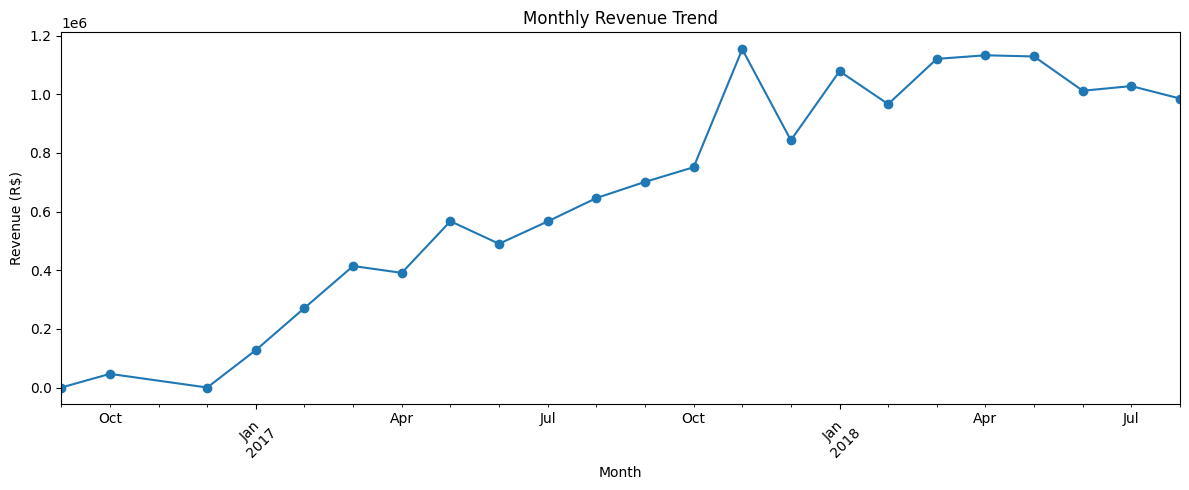

In [43]:
import matplotlib.pyplot as plt

monthly_revenue.plot(kind='line', figsize=(12,5), marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [44]:
print(orders['order_purchase_timestamp'].max())

2018-10-17 17:30:18


In [45]:
orders_per_customer = orders.merge(customers, on='customer_id')['customer_unique_id'].value_counts()
print(orders_per_customer.describe())

count    96096.000000
mean         1.034809
std          0.214384
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         17.000000
Name: count, dtype: float64


In [46]:
repeat_customers = (orders_per_customer > 1).sum()
one_time_customers = (orders_per_customer == 1).sum()

print("One-time buyers:", one_time_customers)
print("Repeat buyers:", repeat_customers)
print("Repeat rate:", round(repeat_customers / (repeat_customers + one_time_customers) * 100, 2), "%")

One-time buyers: 93099
Repeat buyers: 2997
Repeat rate: 3.12 %


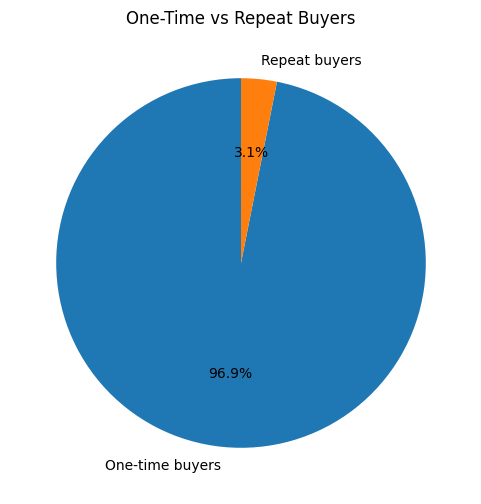

In [47]:
import matplotlib.pyplot as plt

labels = ['One-time buyers', 'Repeat buyers']
values = [one_time_customers, repeat_customers]

plt.figure(figsize=(6,6))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('One-Time vs Repeat Buyers')
plt.show()

In [48]:
orders_with_customer = orders.merge(customers, on='customer_id')

# Get each customer's order dates, sorted
customer_orders = orders_with_customer.sort_values('order_purchase_timestamp').groupby('customer_unique_id')['order_purchase_timestamp'].apply(list)

# Filter to only customers with 2+ orders
repeat_customer_orders = customer_orders[customer_orders.apply(len) > 1]

# Calculate gap between 1st and 2nd purchase
gaps = repeat_customer_orders.apply(lambda dates: (dates[1] - dates[0]).days)

print(gaps.describe())

count    2997.000000
mean       79.990657
std       110.088130
min         0.000000
25%         0.000000
50%        27.000000
75%       123.000000
max       608.000000
Name: order_purchase_timestamp, dtype: float64


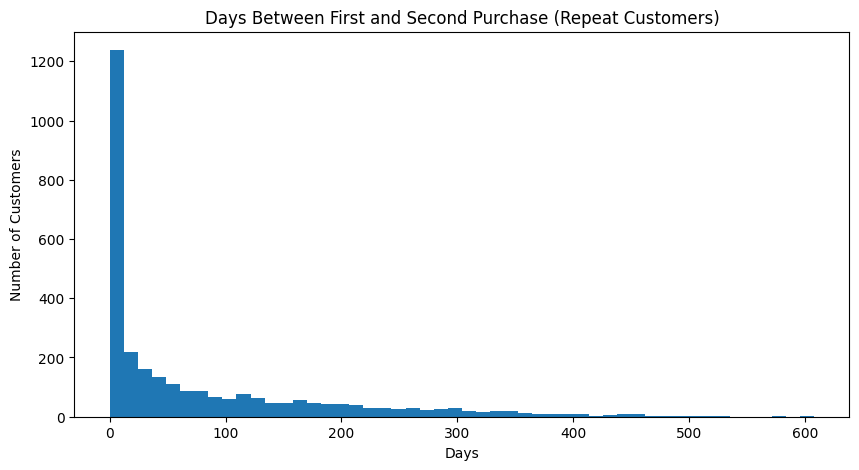

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(gaps, bins=50)
plt.title('Days Between First and Second Purchase (Repeat Customers)')
plt.xlabel('Days')
plt.ylabel('Number of Customers')
plt.show()

In [50]:
# Set a reference date (day after the last order in the dataset)
reference_date = orders['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# Merge orders with customers and revenue
orders_full = orders.merge(customers, on='customer_id').merge(order_revenue, on='order_id', how='left')

rfm = orders_full.groupby('customer_unique_id').agg(
    recency=('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('total_order_value', 'sum')
).reset_index()

print(rfm.shape)
rfm.head()

(96096, 4)


,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19
2,0000f46a3911fa3c0805444483337064,586,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89


In [51]:
# Recency: LOWER is better (recently active), so we reverse the labels
rfm['R_score'] = pd.qcut(rfm['recency'], 4, labels=[4, 3, 2, 1])

# Frequency: HIGHER is better — but since most customers have frequency=1, use rank-based cutting
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])

# Monetary: HIGHER is better
rfm['M_score'] = pd.qcut(rfm['monetary'], 4, labels=[1, 2, 3, 4])

rfm[['R_score', 'F_score', 'M_score']] = rfm[['R_score', 'F_score', 'M_score']].astype(int)

print(rfm.head())

                 customer_unique_id  recency  frequency  monetary  R_score  \
0  0000366f3b9a7992bf8c76cfdf3221e2      161          1    141.90        4   
1  0000b849f77a49e4a4ce2b2a4ca5be3f      164          1     27.19        4   
2  0000f46a3911fa3c0805444483337064      586          1     86.22        1   
3  0000f6ccb0745a6a4b88665a16c9f078      370          1     43.62        2   
4  0004aac84e0df4da2b147fca70cf8255      337          1    196.89        2   

   F_score  M_score  
0        1        3  
1        1        1  
2        1        2  
3        1        1  
4        1        4  


In [52]:
rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

def segment_customer(row):
    if row['R_score'] >= 3 and row['F_score'] >= 3:
        return 'Champions'
    elif row['R_score'] >= 3 and row['F_score'] < 3:
        return 'New/Promising'
    elif row['R_score'] < 3 and row['F_score'] >= 3:
        return 'Loyal but Fading'
    elif row['R_score'] <= 2 and row['F_score'] <= 2 and row['RFM_score'] <= 5:
        return 'Lost'
    else:
        return 'At Risk'

rfm['segment'] = rfm.apply(segment_customer, axis=1)

print(rfm['segment'].value_counts())

segment
Champions           24108
New/Promising       23967
Loyal but Fading    23940
Lost                12447
At Risk             11634
Name: count, dtype: int64


In [53]:
segment_summary = rfm.groupby('segment').agg(
    customer_count=('customer_unique_id', 'count'),
    total_revenue=('monetary', 'sum'),
    avg_revenue=('monetary', 'mean')
).sort_values('total_revenue', ascending=False)

print(segment_summary)

                  customer_count  total_revenue  avg_revenue
segment                                                     
Champions                  24108     4193364.96   173.940806
Loyal but Fading           23940     4035586.97   168.570884
New/Promising              23967     3874006.05   161.639173
At Risk                    11634     3028354.41   260.302081
Lost                       12447      877559.73    70.503714


In [54]:
at_risk_revenue = rfm[rfm['segment'] == 'At Risk']['monetary'].sum()
lost_revenue = rfm[rfm['segment'] == 'Lost']['monetary'].sum()

print(f"Revenue tied to At Risk customers: R${at_risk_revenue:,.2f}")
print(f"Revenue tied to Lost customers: R${lost_revenue:,.2f}")
print(f"Estimated 15% win-back value: R${(at_risk_revenue * 0.15):,.2f}")

Revenue tied to At Risk customers: R$3,028,354.41
Revenue tied to Lost customers: R$877,559.73
Estimated 15% win-back value: R$454,253.16


In [55]:
at_risk_ids = rfm[rfm['segment'] == 'At Risk']['customer_unique_id']
at_risk_orders = orders_full[orders_full['customer_unique_id'].isin(at_risk_ids)]

# Merge with reviews to check satisfaction
at_risk_with_reviews = at_risk_orders.merge(reviews, on='order_id', how='left')
print("Avg review score (At Risk):", at_risk_with_reviews['review_score'].mean())
print("Avg review score (All):", reviews['review_score'].mean())

Avg review score (At Risk): 4.015789017090309
Avg review score (All): 4.08642062404257


In [56]:
orders_full['order_month'] = orders_full['order_purchase_timestamp'].dt.to_period('M')
orders_full['cohort_month'] = orders_full.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('M')

cohort_data = orders_full.groupby(['cohort_month', 'order_month'])['customer_unique_id'].nunique().reset_index()
cohort_data['period_number'] = (cohort_data['order_month'] - cohort_data['cohort_month']).apply(lambda x: x.n)

cohort_pivot = cohort_data.pivot(index='cohort_month', columns='period_number', values='customer_unique_id')
cohort_size = cohort_pivot.iloc[:,0]
retention = cohort_pivot.divide(cohort_size, axis=0)

print(retention.iloc[:12, :6].round(3))

period_number    0      1      2      3      4      5
cohort_month                                         
2016-09        1.0    NaN    NaN    NaN    NaN    NaN
2016-10        1.0    NaN    NaN    NaN    NaN    NaN
2016-12        1.0  1.000    NaN    NaN    NaN    NaN
2017-01        1.0  0.004  0.003  0.001  0.004  0.001
2017-02        1.0  0.002  0.003  0.001  0.004  0.001
2017-03        1.0  0.005  0.004  0.004  0.003  0.002
2017-04        1.0  0.006  0.002  0.002  0.003  0.003
2017-05        1.0  0.005  0.005  0.004  0.003  0.003
2017-06        1.0  0.005  0.004  0.004  0.003  0.004
2017-07        1.0  0.005  0.004  0.003  0.003  0.002
2017-08        1.0  0.007  0.003  0.003  0.004  0.005
2017-09        1.0  0.007  0.005  0.003  0.005  0.002


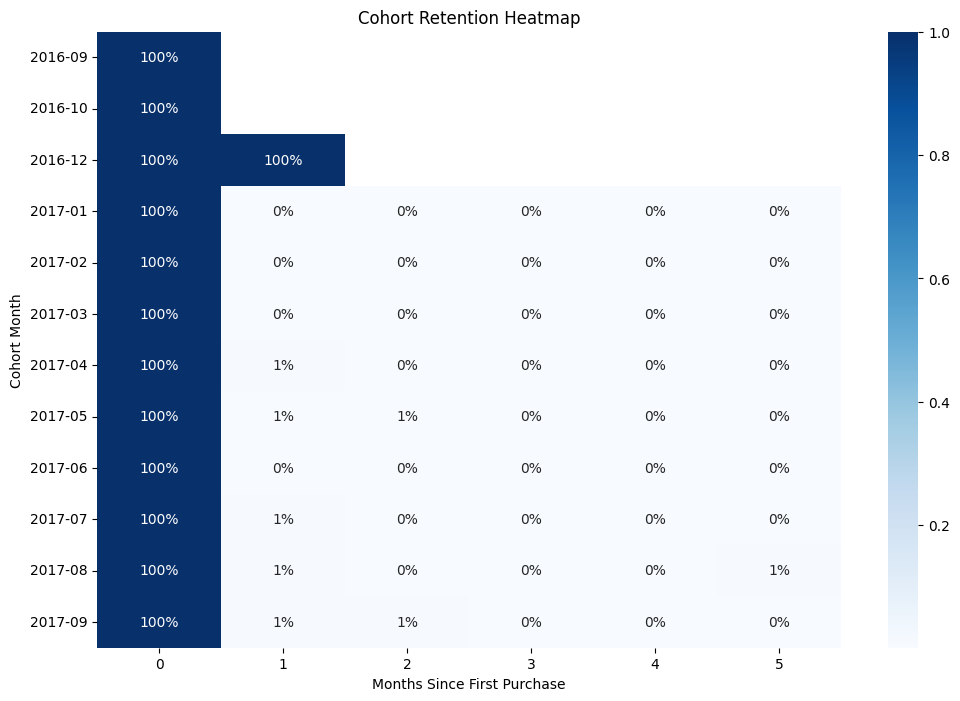

In [57]:
import seaborn as sns
plt.figure(figsize=(12,8))
sns.heatmap(retention.iloc[:12, :6], annot=True, fmt='.0%', cmap='Blues')
plt.title('Cohort Retention Heatmap')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month')
plt.show()

In [58]:
rfm.to_csv('data/cleaned/rfm_segments.csv', index=False)
segment_summary.to_csv('data/cleaned/segment_summary.csv')
print("Saved.")

Saved.
